# NOAA PMN Dataset Exploration & Cleaning for HAB Prediction

This notebook walks through the NOAA NCCOS Phytoplankton Monitoring Network (PMN) export step by step:

For this project, PMN should be treated as a **HAB-related auxiliary feature source**, not a direct HAB label dataset. The analysis is most useful when narrowed to **California weekly observations**, but PMN only overlaps with a subset of the CalHABMAP California pier list rather than all target piers.

In the current data pull, the clearest PMN overlap is with **Santa Cruz Wharf**, **Stearns Wharf / Sea Center**, and **Monterey Wharf / Wharf 2 Monterey**.

1. **Setup** — define the NOAA ERDDAP endpoint, date range, and output path
2. **Download** — pull PMN data in weekly windows and merge the raw export
3. **Prepare** — validate the CSV and build an analysis copy for cleaning
4. **Explore** — inspect structure, spatial coverage, top sites, and species patterns
5. **Visualize** — chart weekly trends, seasonality, environmental structure, and a sample-site quick look
6. **Review QA** — inspect NOAA quality-assurance flag frequencies
7. **Summarize** — highlight variables that may be useful for HAB prediction


## 1. Setup

In [1]:
from pathlib import Path
from urllib.parse import quote

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_URL = "https://www.ncei.noaa.gov/erddap/tabledap/bedi_PMN.csv"
START_DATE = pd.Timestamp("2017-01-01", tz="UTC")
END_DATE = pd.Timestamp("2026-12-31 23:59:59", tz="UTC")
CHUNK_DAYS = 7
NOTEBOOK_DIR = Path("notebooks/noaa_pmn") if Path("notebooks/noaa_pmn").exists() else Path(".")
DATA_DIR = NOTEBOOK_DIR / "data"
OUTPUT_CSV = DATA_DIR / "noaa_pmn_all_data_2017_2026_weekly.csv"
LOCAL_SOURCE_CSVS = [
    OUTPUT_CSV,
    DATA_DIR / "noaa_pmn_all_data_2001_2026.csv",
]

COLUMNS = [
    "time",
    "latitude",
    "longitude",
    "abundance",
    "air_temp",
    "datetime",
    "salinity",
    "sample_site",
    "spec_name",
    "water_temp",
    "weather",
    "winddirect",
    "tide",
    "count",
    "ph",
    "dissoxygen",
    "secchidisk",
    "comments",
    "windspeed",
    "QA_air_temp",
    "QA_latitude",
    "QA_longitude",
    "QA_salinity",
    "QA_sample_site",
    "QA_water_temp",
    "QA_count",
    "QA_ph",
    "QA_dissoxygen",
    "QA_windspeed",
]

NUMERIC_COLUMNS = [
    "latitude",
    "longitude",
    "air_temp",
    "salinity",
    "water_temp",
    "count",
    "ph",
    "dissoxygen",
    "secchidisk",
    "windspeed",
    "QA_air_temp",
    "QA_latitude",
    "QA_longitude",
    "QA_salinity",
    "QA_sample_site",
    "QA_water_temp",
    "QA_count",
    "QA_ph",
    "QA_dissoxygen",
    "QA_windspeed",
]

ENVIRONMENTAL_COLUMNS = [
    "water_temp",
    "air_temp",
    "salinity",
    "ph",
    "dissoxygen",
    "secchidisk",
    "windspeed",
    "count",
]

QA_COLUMNS = [col for col in COLUMNS if col.startswith("QA_")]
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## 2. Download and Export Raw Data

The NOAA PMN table is pulled in **weekly windows** so the export is more resilient to large requests.
Each successful chunk is logged, then all loaded windows are merged into one raw CSV.

In [2]:
def build_weekly_windows(start_date=START_DATE, end_date=END_DATE, chunk_days=CHUNK_DAYS):
    windows = []
    current_start = start_date

    while current_start <= end_date:
        current_end = min(current_start + pd.Timedelta(days=chunk_days) - pd.Timedelta(seconds=1), end_date)
        windows.append((current_start, current_end))
        current_start = current_start + pd.Timedelta(days=chunk_days)

    return windows


def build_chunk_url(chunk_start: pd.Timestamp, chunk_end: pd.Timestamp) -> str:
    cols = quote(",".join(COLUMNS), safe=",")
    start_str = chunk_start.strftime("%Y-%m-%dT%H:%M:%SZ")
    end_str = chunk_end.strftime("%Y-%m-%dT%H:%M:%SZ")
    return f"{BASE_URL}?{cols}&time%3E={start_str}&time%3C={end_str}"


def fetch_chunk(chunk_start: pd.Timestamp, chunk_end: pd.Timestamp) -> pd.DataFrame:
    return pd.read_csv(build_chunk_url(chunk_start, chunk_end), skiprows=[1])


def export_full_dataset(start_date=START_DATE, end_date=END_DATE, chunk_days=CHUNK_DAYS):
    weekly_frames = []
    load_log = []

    local_source = next((path for path in LOCAL_SOURCE_CSVS if path.exists()), None)
    windows = build_weekly_windows(start_date, end_date, chunk_days)

    if local_source is not None:
        raw_df = pd.read_csv(local_source)
        raw_times = pd.to_datetime(raw_df["time"], utc=True, errors="coerce")
        raw_df = raw_df.loc[(raw_times >= start_date) & (raw_times <= end_date)].copy()
        raw_df = raw_df.reindex(columns=COLUMNS)

        filtered_times = pd.to_datetime(raw_df["time"], utc=True, errors="coerce")
        for chunk_start, chunk_end in windows:
            mask = (filtered_times >= chunk_start) & (filtered_times <= chunk_end)
            rows = int(mask.sum())
            load_log.append({
                "chunk_start": chunk_start,
                "chunk_end": chunk_end,
                "status": "loaded",
                "rows": rows,
                "columns": len(COLUMNS),
                "url": build_chunk_url(chunk_start, chunk_end),
                "error": "",
            })

        OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
        raw_df.to_csv(OUTPUT_CSV, index=False)
        load_log_df = pd.DataFrame(load_log)

        print(f"Loaded NOAA PMN data from local cache: {local_source.resolve()}")
        print(f"Saved filtered raw export to: {OUTPUT_CSV.resolve()}")
        print(f"Merged raw dataset shape: {raw_df.shape}")
        print(f"Weekly windows represented: {len(load_log_df):,}")

        return raw_df, load_log_df

    for chunk_start, chunk_end in windows:
        try:
            df_chunk = fetch_chunk(chunk_start, chunk_end)
            weekly_frames.append(df_chunk)
            load_log.append({
                "chunk_start": chunk_start,
                "chunk_end": chunk_end,
                "status": "loaded",
                "rows": len(df_chunk),
                "columns": df_chunk.shape[1],
                "url": build_chunk_url(chunk_start, chunk_end),
                "error": "",
            })
            print(f"Loaded {chunk_start:%Y-%m-%d} to {chunk_end:%Y-%m-%d}: {df_chunk.shape}")
        except Exception as exc:
            load_log.append({
                "chunk_start": chunk_start,
                "chunk_end": chunk_end,
                "status": "failed",
                "rows": 0,
                "columns": 0,
                "url": build_chunk_url(chunk_start, chunk_end),
                "error": str(exc),
            })
            print(f"Failed {chunk_start:%Y-%m-%d} to {chunk_end:%Y-%m-%d}: {exc}")

    if weekly_frames:
        raw_df = pd.concat(weekly_frames, ignore_index=True)
    else:
        raw_df = pd.DataFrame(columns=COLUMNS)

    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    raw_df.to_csv(OUTPUT_CSV, index=False)

    load_log_df = pd.DataFrame(load_log)
    print(f"\nSaved raw export to: {OUTPUT_CSV.resolve()}")
    print(f"Merged raw dataset shape: {raw_df.shape}")
    print(f"Weekly windows attempted: {len(load_log_df):,}")

    return raw_df, load_log_df


raw_df, load_log_df = export_full_dataset()
display(load_log_df.head())
display(load_log_df.tail())


                chunk_start                 chunk_end  status  rows  columns                                                                                                                                                                                                                                                                                                                                                                                                               url error
0 2017-01-01 00:00:00+00:00 2017-01-07 23:59:59+00:00  loaded    50       29  https://www.ncei.noaa.gov/erddap/tabledap/bedi_PMN.csv?time,latitude,longitude,abundance,air_temp,datetime,salinity,sample_site,spec_name,water_temp,weather,winddirect,tide,count,ph,dissoxygen,secchidisk,comments,windspeed,QA_air_temp,QA_latitude,QA_longitude,QA_salinity,QA_sample_site,QA_water_temp,QA_count,QA_ph,QA_dissoxygen,QA_windspeed&time%3E=2017-01-01T00:00:00Z&time%3C=2017-01-07T23:59:59Z      
1 2017-01-08 00:00:00+00:00 20

                  chunk_start                 chunk_end  status  rows  columns                                                                                                                                                                                                                                                                                                                                                                                                               url error
517 2026-11-29 00:00:00+00:00 2026-12-05 23:59:59+00:00  loaded     0       29  https://www.ncei.noaa.gov/erddap/tabledap/bedi_PMN.csv?time,latitude,longitude,abundance,air_temp,datetime,salinity,sample_site,spec_name,water_temp,weather,winddirect,tide,count,ph,dissoxygen,secchidisk,comments,windspeed,QA_air_temp,QA_latitude,QA_longitude,QA_salinity,QA_sample_site,QA_water_temp,QA_count,QA_ph,QA_dissoxygen,QA_windspeed&time%3E=2026-11-29T00:00:00Z&time%3C=2026-12-05T23:59:59Z      
518 2026-12-06 00:00:00+00

Loaded NOAA PMN data from local cache: /mnt/shared/Documents/code/acm-project/Harmful-Algal-Bloom-Predictor/notebooks/noaa_pmn/data/noaa_pmn_all_data_2001_2026.csv
Saved filtered raw export to: /mnt/shared/Documents/code/acm-project/Harmful-Algal-Bloom-Predictor/notebooks/noaa_pmn/data/noaa_pmn_all_data_2017_2026_weekly.csv
Merged raw dataset shape: (39846, 29)
Weekly windows represented: 522


## 3. Validate Export and Prepare an Analysis Copy

The merged raw CSV should preserve NOAA's selected columns exactly.
After validation, we create `analysis_df` so cleaning and feature work do not alter the raw export.

In [3]:
exported_header = pd.read_csv(OUTPUT_CSV, nrows=0).columns.tolist()

assert exported_header == COLUMNS, (
    f"Unexpected export columns.\nExpected: {COLUMNS}\nFound: {exported_header}"
)
assert len(raw_df) == load_log_df.loc[load_log_df["status"] == "loaded", "rows"].sum()
assert load_log_df["chunk_start"].min() == START_DATE
assert load_log_df["chunk_end"].max() == END_DATE

print("Exported CSV columns verified.")
print(f"Export row count verified: {len(raw_df):,}")
print(f"First weekly window: {load_log_df['chunk_start'].min()} to {load_log_df.loc[load_log_df['chunk_start'].idxmin(), 'chunk_end']}")
print(f"Last weekly window: {load_log_df.loc[load_log_df['chunk_end'].idxmax(), 'chunk_start']} to {load_log_df['chunk_end'].max()}")


Exported CSV columns verified.
Export row count verified: 39,846
First weekly window: 2017-01-01 00:00:00+00:00 to 2017-01-07 23:59:59+00:00
Last weekly window: 2026-12-27 00:00:00+00:00 to 2026-12-31 23:59:59+00:00


In [4]:
analysis_df = raw_df.copy()

for col in ["time", "datetime"]:
    analysis_df[col] = pd.to_datetime(analysis_df[col], utc=True, errors="coerce")

for col in NUMERIC_COLUMNS:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df[NUMERIC_COLUMNS] = analysis_df[NUMERIC_COLUMNS].replace(-9999, np.nan)
analysis_df["year"] = analysis_df["time"].dt.year
analysis_df["month"] = analysis_df["time"].dt.month
analysis_df["month_name"] = pd.Categorical(
    analysis_df["time"].dt.month.map(lambda x: MONTH_LABELS[int(x) - 1] if pd.notna(x) else np.nan),
    categories=MONTH_LABELS,
    ordered=True,
)
analysis_df["week_start"] = (
    analysis_df["time"]
    .dt.tz_convert(None)
    .dt.to_period("W-SUN")
    .dt.start_time
)

analysis_df.head()


                            time  latitude  longitude abundance  air_temp                  datetime  salinity         sample_site           spec_name  water_temp  ... QA_sample_site QA_water_temp QA_count  QA_ph  QA_dissoxygen  QA_windspeed  year month  month_name  week_start
450240 2017-07-22 13:00:48+00:00  -23.7675  -45.35111   Present      25.0 2017-07-22 13:00:48+00:00      36.5  BR - Ilhabela Dock    Alexandrium spp.        21.0  ...              1             1      NaN    NaN            NaN           NaN  2017     7         Jul  2017-07-17
450241 2017-07-22 13:00:48+00:00  -23.7675  -45.35111   Present      25.0 2017-07-22 13:00:48+00:00      36.5  BR - Ilhabela Dock      Centric Diatom        21.0  ...              1             1      NaN    NaN            NaN           NaN  2017     7         Jul  2017-07-17
450242 2017-07-22 13:00:48+00:00  -23.7675  -45.35111   Present      25.0 2017-07-22 13:00:48+00:00      36.5  BR - Ilhabela Dock       Ceratium spp.        21.0  ...   

## 4. Explore the PMN Dataset

### 4a. Basic Structure and Coverage

In [5]:
print(f"Raw dataset shape: {raw_df.shape}")
print(f"Analysis dataset shape: {analysis_df.shape}")
print(f"Date coverage: {analysis_df['time'].min()} to {analysis_df['time'].max()}")
print("\nColumns:")
print(list(raw_df.columns))
print("\nDtypes:")
print(analysis_df.dtypes)

chunk_status_summary = load_log_df.groupby("status").agg(chunks=("status", "size"), rows=("rows", "sum")).reset_index()
display(chunk_status_summary)


   status  chunks   rows
0  loaded     522  39846

Raw dataset shape: (39846, 29)
Analysis dataset shape: (39846, 33)
Date coverage: 2017-01-03 04:35:12+00:00 to 2025-12-20 15:15:00+00:00

Columns:
['time', 'latitude', 'longitude', 'abundance', 'air_temp', 'datetime', 'salinity', 'sample_site', 'spec_name', 'water_temp', 'weather', 'winddirect', 'tide', 'count', 'ph', 'dissoxygen', 'secchidisk', 'comments', 'windspeed', 'QA_air_temp', 'QA_latitude', 'QA_longitude', 'QA_salinity', 'QA_sample_site', 'QA_water_temp', 'QA_count', 'QA_ph', 'QA_dissoxygen', 'QA_windspeed']

Dtypes:
time              datetime64[us, UTC]
latitude                      float64
longitude                     float64
abundance                         str
air_temp                      float64
datetime          datetime64[us, UTC]
salinity                      float64
sample_site                       str
spec_name                         str
water_temp                    float64
weather                           str
winddirect                        str
tide        

### 4b. Spatial Coverage of Sample Sites

Each point represents one PMN sample site positioned by its median reported latitude and longitude.
Marker size reflects the number of observations, and color reflects how many unique species were recorded there.

                                 sample_site   latitude   longitude  observations  species
143                      GA - Skidaway River  31.931440  -81.074570          3269      104
299                         SC - Marlin Quay  33.553037  -79.020361          2114       73
79                       FL - Caloosahatchee  26.620800  -81.929500          2050      113
303                SC - North Pawleys Island  33.442360  -79.115317          1826       50
316                SC - South Pawleys Island  33.403022  -79.137311          1423       47
91                          FL - Guana River  30.022986  -81.328338          1387      122
89                           FL - Guana Lake  30.023067  -81.328274          1265      131
37                 CA - Marina Del Ray Jetty  33.962698 -118.461934          1014      127
131                     FL - Wrights Landing  30.004874  -81.339621           732       78
82           FL - Florida Oceanographic Dock  27.214333  -80.183969           641       69

cell_12:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


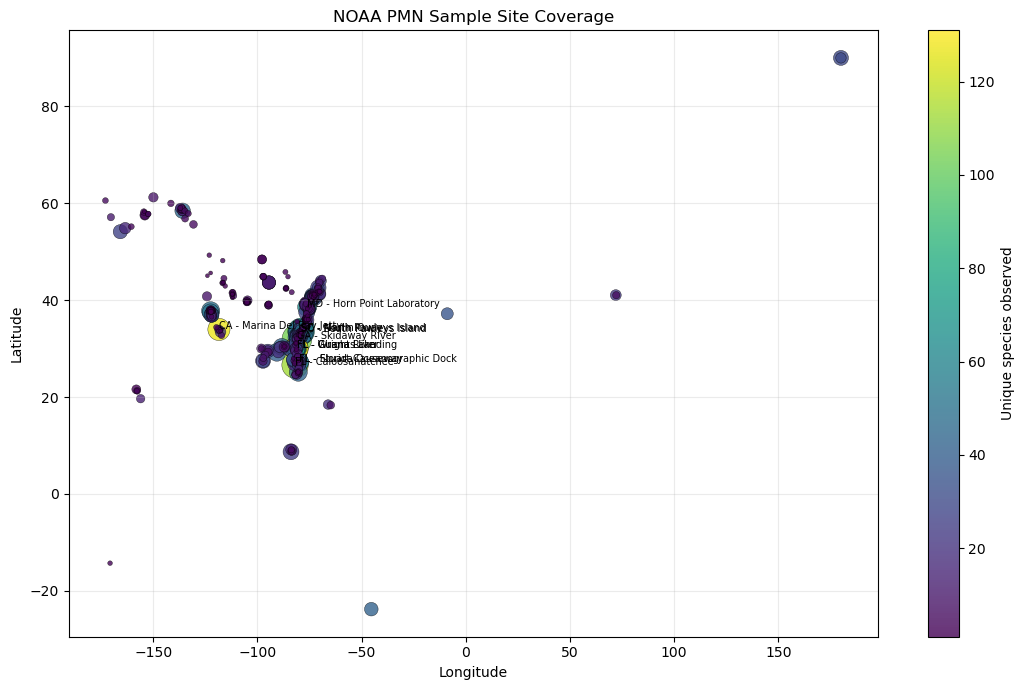

In [6]:
site_summary = (
    analysis_df.dropna(subset=["sample_site"])
    .groupby("sample_site")
    .agg(
        latitude=("latitude", "median"),
        longitude=("longitude", "median"),
        observations=("sample_site", "size"),
        species=("spec_name", "nunique"),
    )
    .reset_index()
    .dropna(subset=["latitude", "longitude"])
    .sort_values("observations", ascending=False)
)

display(site_summary.head(15))

if site_summary.empty:
    print("No site coordinates are available for a coverage plot.")
else:
    fig, ax = plt.subplots(figsize=(11, 7))

    scatter = ax.scatter(
        site_summary["longitude"],
        site_summary["latitude"],
        s=site_summary["observations"].clip(lower=1).pow(0.5) * 8,
        c=site_summary["species"],
        cmap="viridis",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.3,
    )

    for _, row in site_summary.head(12).iterrows():
        ax.text(row["longitude"] + 0.15, row["latitude"] + 0.1, row["sample_site"], fontsize=7)

    ax.set_title("NOAA PMN Sample Site Coverage")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.25)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Unique species observed")
    plt.tight_layout()
    plt.show()


### 4c. Top Sample Sites and Species

These ranked views show where the network samples most heavily and which taxa appear most often in the PMN records.

                                         records
sample_site                                     
SC - Hogs Inlet                              484
FL - San Sebastain River                     484
SC - Colleton River, Callawassie Island      501
MD - Horn Point Laboratory                   545
FL - Stuart Causeway                         623
FL - Florida Oceanographic Dock              641
FL - Wrights Landing                         732
CA - Marina Del Ray Jetty                   1014
FL - Guana Lake                             1265
FL - Guana River                            1387
SC - South Pawleys Island                   1423
SC - North Pawleys Island                   1826
FL - Caloosahatchee                         2050
SC - Marlin Quay                            2114
GA - Skidaway River                         3269

                       records
spec_name                     
Protoperidinium spp.       760
Asterionellopsis spp.      881
Dinoflagellates            911
Zooplankton               1083
Odontella spp.            1112
Nitzschia spp.            1166
Thalassionema spp.        1196
Rhizosolenia spp.         1471
Navicula spp.             1875
Pleurosigma spp.          1905
Centric Diatom            1909
Pennate Diatom            1920
Skeletonema spp.          2031
Coscinodiscus spp.        2464
Chaetoceros spp.          2672

           records
abundance         
Present      39299
Elevated       547

Top sample sites

Top species

Abundance categories


cell_14:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


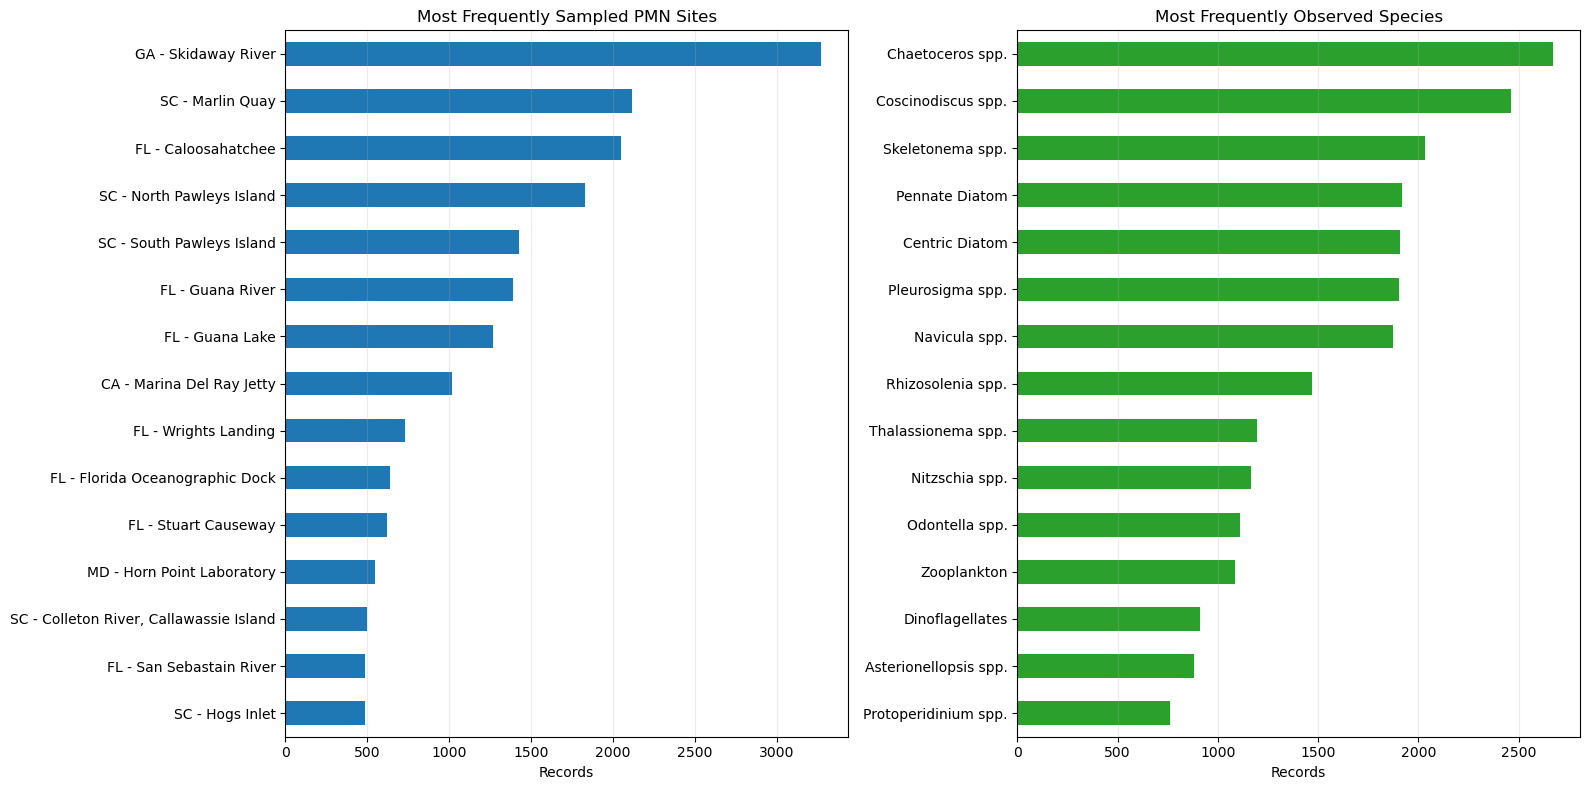

In [7]:
top_sites = analysis_df["sample_site"].fillna("<missing>").value_counts().head(15).sort_values()
top_species = analysis_df["spec_name"].fillna("<missing>").value_counts().head(15).sort_values()
abundance_counts = analysis_df["abundance"].fillna("<missing>").value_counts()

print("Top sample sites")
display(top_sites.to_frame("records"))
print("\nTop species")
display(top_species.to_frame("records"))
print("\nAbundance categories")
display(abundance_counts.to_frame("records"))

if top_sites.empty or top_species.empty:
    print("Not enough data is available for site/species bar charts.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    top_sites.plot(kind="barh", ax=axes[0], color="tab:blue")
    axes[0].set_title("Most Frequently Sampled PMN Sites")
    axes[0].set_xlabel("Records")
    axes[0].set_ylabel("")
    axes[0].grid(axis="x", alpha=0.25)

    top_species.plot(kind="barh", ax=axes[1], color="tab:green")
    axes[1].set_title("Most Frequently Observed Species")
    axes[1].set_xlabel("Records")
    axes[1].set_ylabel("")
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()


### 4d. Monthly Seasonality

This view compresses the full record into a monthly cycle so it is easier to spot seasonal shifts in sampling effort, cell counts, and water temperature.

   month_name  observations  median_count  median_water_temp
0         Jan          3741           NaN               13.0
1         Feb          3409           NaN               14.0
2         Mar          3656           NaN               16.0
3         Apr          3354           NaN               20.0
4         May          2955           NaN               25.0
5         Jun          3341           NaN               27.0
6         Jul          3596           NaN               28.0
7         Aug          3508           NaN               28.0
8         Sep          3242           NaN               27.0
9         Oct          3467           NaN               23.0
10        Nov          3187           NaN               17.0
11        Dec          2390           NaN               14.0

cell_16:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


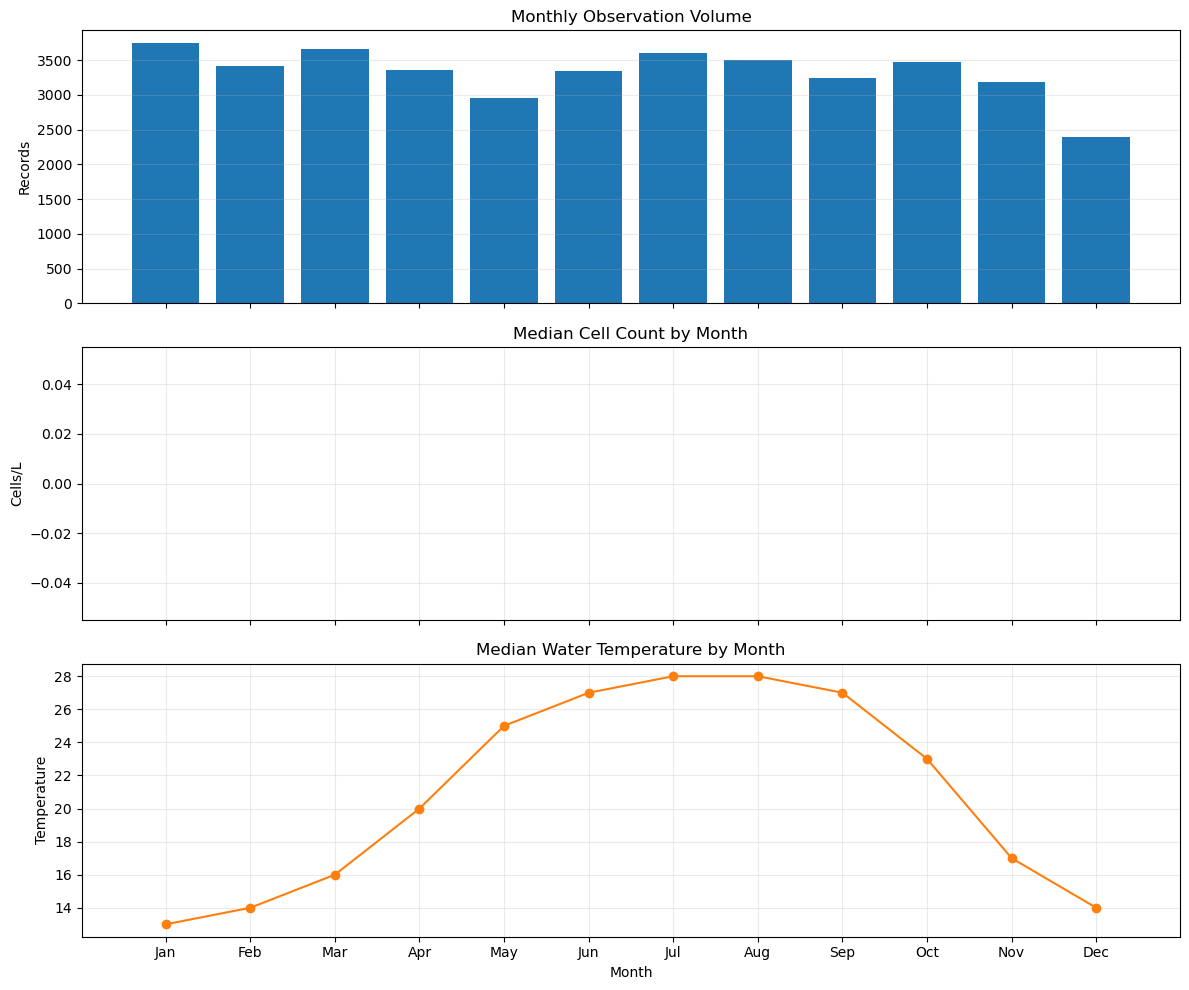

In [8]:
monthly_summary = (
    analysis_df.dropna(subset=["month_name"])
    .groupby("month_name", observed=False)
    .agg(
        observations=("sample_site", "size"),
        median_count=("count", "median"),
        median_water_temp=("water_temp", "median"),
    )
    .reset_index()
)

display(monthly_summary)

if monthly_summary.empty:
    print("No monthly seasonality summary is available because no dated rows were loaded.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    axes[0].bar(monthly_summary["month_name"].astype(str), monthly_summary["observations"], color="tab:blue")
    axes[0].set_title("Monthly Observation Volume")
    axes[0].set_ylabel("Records")
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].plot(monthly_summary["month_name"].astype(str), monthly_summary["median_count"], color="tab:red", marker="o")
    axes[1].set_title("Median Cell Count by Month")
    axes[1].set_ylabel("Cells/L")
    axes[1].grid(True, alpha=0.25)

    axes[2].plot(monthly_summary["month_name"].astype(str), monthly_summary["median_water_temp"], color="tab:orange", marker="o")
    axes[2].set_title("Median Water Temperature by Month")
    axes[2].set_ylabel("Temperature")
    axes[2].set_xlabel("Month")
    axes[2].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


## 5. Visualize Weekly Trends and Environmental Structure

### 5a. Weekly Count Trends

  week_start  observations  median_count  max_count
0 2017-01-02            50           NaN        NaN
1 2017-01-09            83           NaN        NaN
2 2017-01-16            27           NaN        NaN
3 2017-01-23            50           NaN        NaN
4 2017-01-30            64           NaN        NaN

    week_start  observations  median_count  max_count
442 2025-11-17           198           NaN        NaN
443 2025-11-24            20           NaN        NaN
444 2025-12-01           103           NaN        NaN
445 2025-12-08            88           NaN        NaN
446 2025-12-15            50           NaN        NaN

cell_19:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


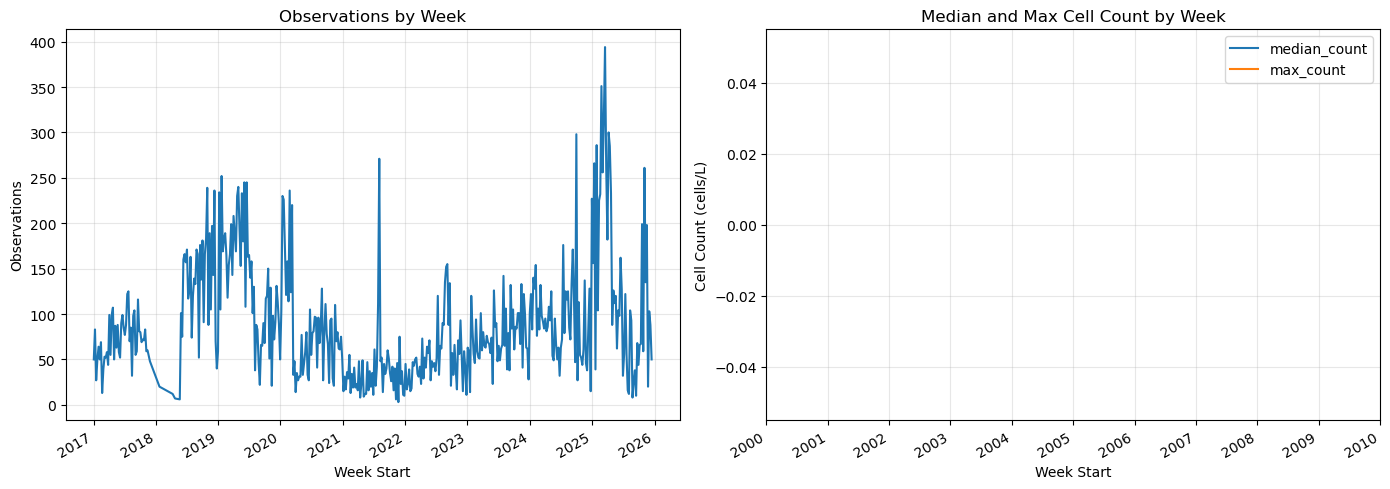

In [9]:
weekly_count_summary = (
    analysis_df.groupby("week_start", dropna=True)["count"]
    .agg(observations="size", median_count="median", max_count="max")
    .reset_index()
)

display(weekly_count_summary.head())
display(weekly_count_summary.tail())

if weekly_count_summary.empty:
    print("No weekly count trends are available because no data was loaded.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    weekly_count_summary.plot(x="week_start", y="observations", ax=axes[0], legend=False, color="tab:blue")
    axes[0].set_title("Observations by Week")
    axes[0].set_xlabel("Week Start")
    axes[0].set_ylabel("Observations")
    axes[0].grid(alpha=0.3)

    weekly_count_summary.plot(x="week_start", y=["median_count", "max_count"], ax=axes[1])
    axes[1].set_title("Median and Max Cell Count by Week")
    axes[1].set_xlabel("Week Start")
    axes[1].set_ylabel("Cell Count (cells/L)")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


### 5b. Environmental Distributions and Correlations

            water_temp  air_temp  salinity        ph  dissoxygen  secchidisk  count
water_temp    1.000000  0.865163 -0.023739  0.026279   -0.137028   -0.108391    NaN
air_temp      0.865163  1.000000 -0.027656 -0.002041   -0.096549   -0.104357    NaN
salinity     -0.023739 -0.027656  1.000000  0.004672    0.025342    0.232623    NaN
ph            0.026279 -0.002041  0.004672  1.000000    0.006452   -0.064820    NaN
dissoxygen   -0.137028 -0.096549  0.025342  0.006452    1.000000   -0.007910    NaN
secchidisk   -0.108391 -0.104357  0.232623 -0.064820   -0.007910    1.000000    NaN
count              NaN       NaN       NaN       NaN         NaN         NaN    NaN

cell_21:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_21:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


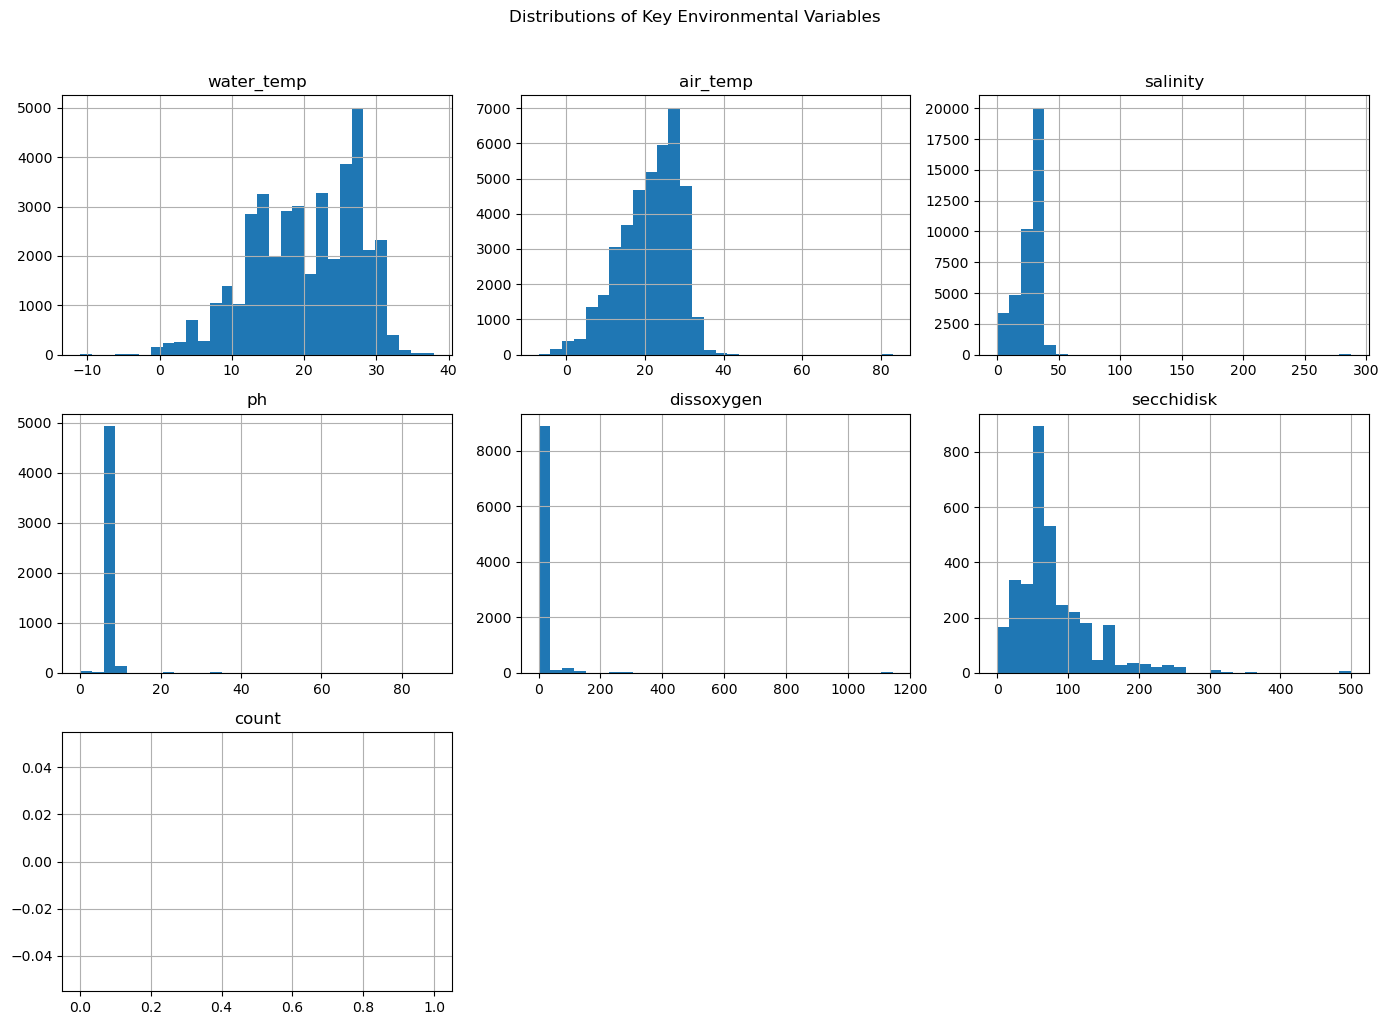

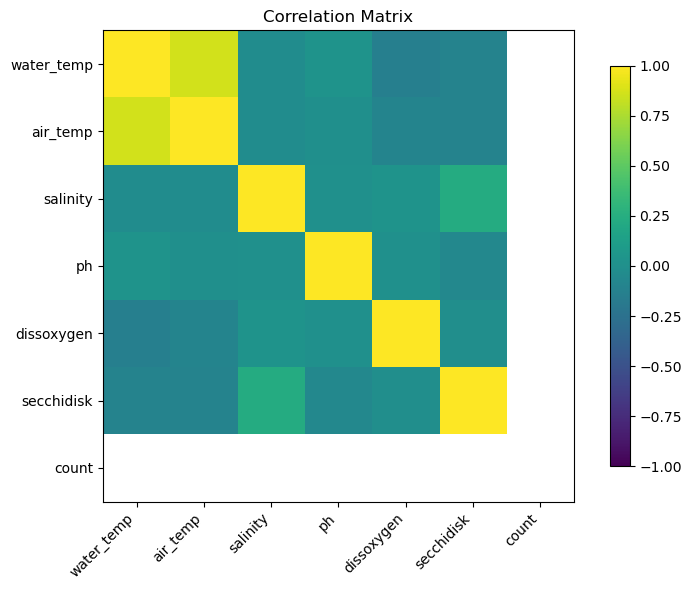

In [10]:
plot_columns = ["water_temp", "air_temp", "salinity", "ph", "dissoxygen", "secchidisk", "count"]
plot_df = analysis_df[plot_columns].dropna(how="all")

if plot_df.empty:
    print("No numeric rows are available for distribution or correlation plots.")
else:
    plot_df.hist(figsize=(14, 10), bins=30)
    plt.suptitle("Distributions of Key Environmental Variables", y=1.02)
    plt.tight_layout()
    plt.show()

    corr = plot_df.corr(numeric_only=True)
    display(corr)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr, cmap="viridis", vmin=-1, vmax=1)
    ax.set_xticks(range(len(plot_columns)))
    ax.set_yticks(range(len(plot_columns)))
    ax.set_xticklabels(plot_columns, rotation=45, ha="right")
    ax.set_yticklabels(plot_columns)
    ax.set_title("Correlation Matrix")
    fig.colorbar(im, ax=ax, shrink=0.85)
    plt.tight_layout()
    plt.show()


### 5c. Quick Look at One Sample Site

This mirrors the style of the OISST notebook by drilling into one representative site and showing how activity and conditions evolve through time.

  week_start  observations  median_count  median_water_temp  median_salinity
0 2017-01-02             5           NaN               15.5             25.0
1 2017-01-09             5           NaN               12.0             25.0
2 2017-01-23             6           NaN               19.0             18.0
3 2017-01-30             4           NaN               14.0             16.0
4 2017-02-06             3           NaN               16.0             15.0

cell_23:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


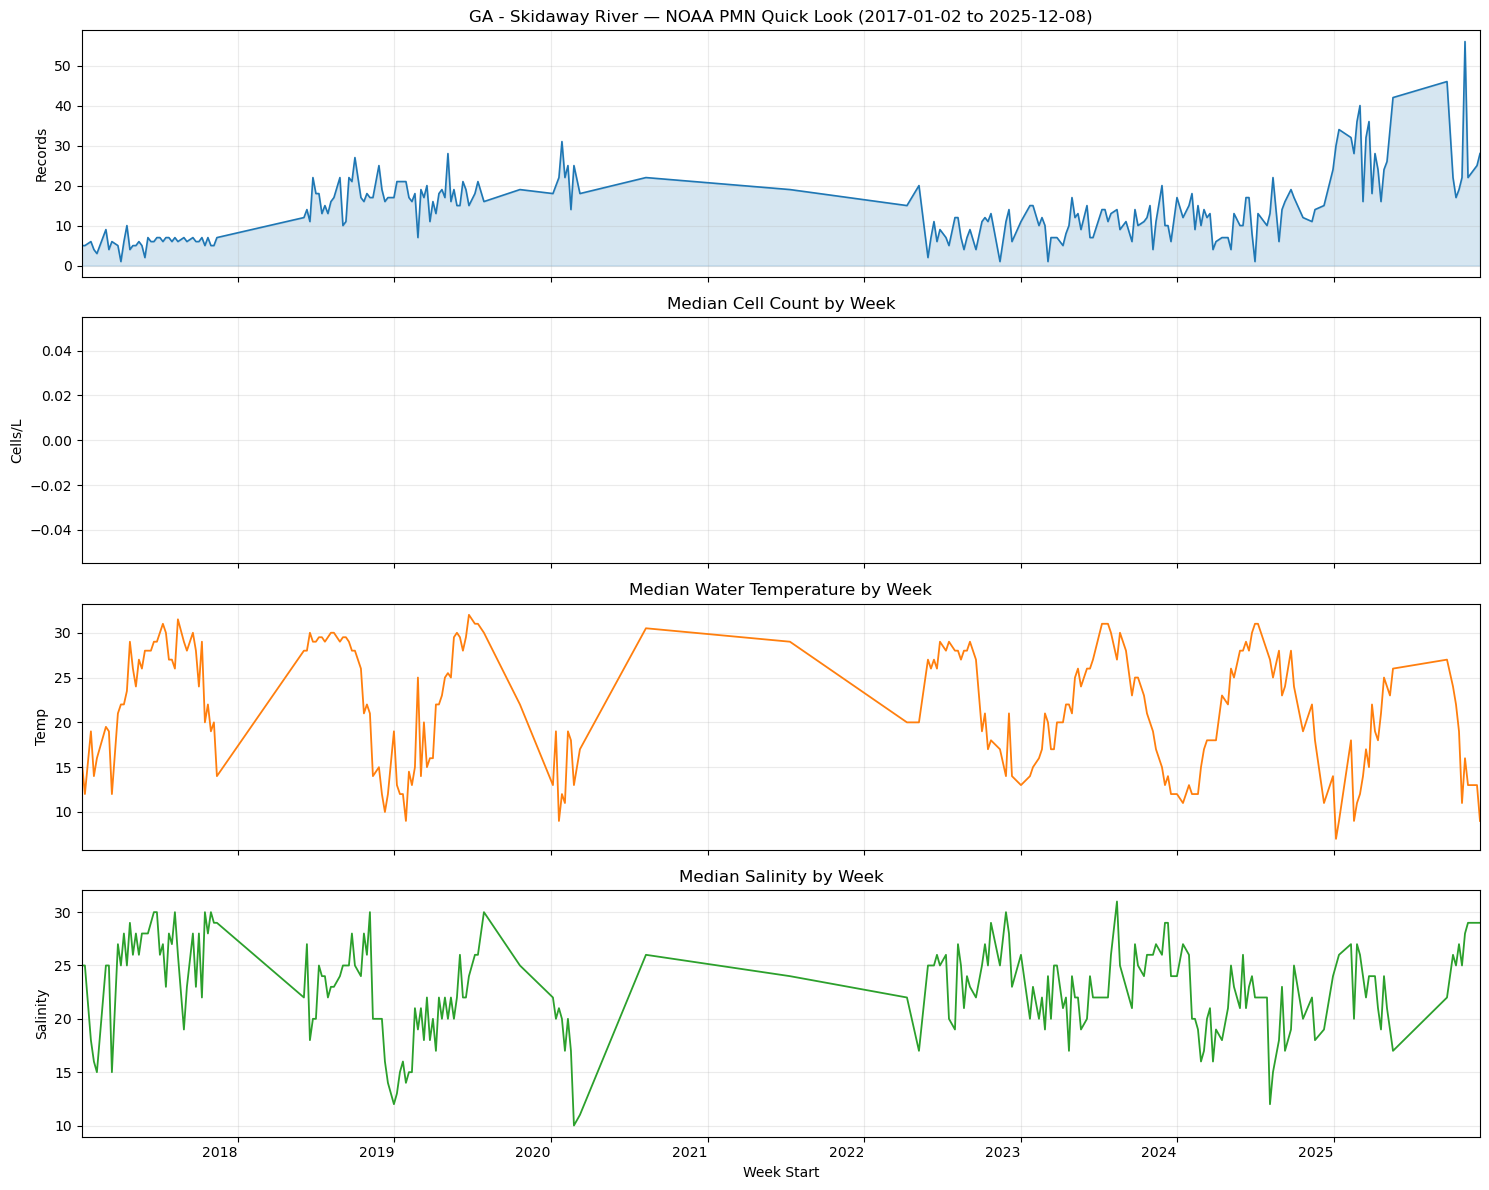

In [11]:
site_counts = analysis_df["sample_site"].dropna().value_counts()

if site_counts.empty:
    print("No sample-site quick look is available because site names are missing.")
else:
    sample_site_name = site_counts.index[0]
    site_df = analysis_df[analysis_df["sample_site"] == sample_site_name].sort_values("time").copy()

    site_weekly = (
        site_df.groupby("week_start")
        .agg(
            observations=("sample_site", "size"),
            median_count=("count", "median"),
            median_water_temp=("water_temp", "median"),
            median_salinity=("salinity", "median"),
        )
        .reset_index()
    )

    display(site_weekly.head())

    if site_weekly.empty:
        print("No weekly site summary could be built for the selected sample site.")
    else:
        date_min = site_weekly["week_start"].min()
        date_max = site_weekly["week_start"].max()
        year_locator = mdates.YearLocator()
        year_fmt = mdates.DateFormatter("%Y")

        fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

        axes[0].fill_between(site_weekly["week_start"], 0, site_weekly["observations"], color="tab:blue", alpha=0.18)
        axes[0].plot(site_weekly["week_start"], site_weekly["observations"], color="tab:blue", linewidth=1.2)
        axes[0].set_ylabel("Records")
        axes[0].set_title(
            f"{sample_site_name} — NOAA PMN Quick Look ({date_min:%Y-%m-%d} to {date_max:%Y-%m-%d})"
        )
        axes[0].grid(True, alpha=0.25)

        axes[1].plot(site_weekly["week_start"], site_weekly["median_count"], color="tab:red", linewidth=1.3)
        axes[1].set_ylabel("Cells/L")
        axes[1].set_title("Median Cell Count by Week")
        axes[1].grid(True, alpha=0.25)

        axes[2].plot(site_weekly["week_start"], site_weekly["median_water_temp"], color="tab:orange", linewidth=1.3)
        axes[2].set_ylabel("Temp")
        axes[2].set_title("Median Water Temperature by Week")
        axes[2].grid(True, alpha=0.25)

        axes[3].plot(site_weekly["week_start"], site_weekly["median_salinity"], color="tab:green", linewidth=1.3)
        axes[3].set_ylabel("Salinity")
        axes[3].set_title("Median Salinity by Week")
        axes[3].grid(True, alpha=0.25)

        for ax in axes:
            ax.set_xlim(date_min, date_max)
            ax.xaxis.set_major_locator(year_locator)
            ax.xaxis.set_major_formatter(year_fmt)

        axes[3].set_xlabel("Week Start")
        fig.autofmt_xdate(rotation=0)
        plt.tight_layout()
        plt.show()


## 6. Review QA Flag Frequencies

NOAA PMN includes QA fields for several measurements and site attributes.
These counts help show which flags are common and which variables may need more filtering downstream.

   flag  records
1  -1.0      140
0   1.0    39699
2   3.0        7

   flag  records
0     1    39350
1     4      496

   flag  records
0     1    39350
1     4      496

   flag  records
1  -1.0      579
0   1.0    39197
2   3.0       41
3   4.0       29


QA_air_temp

QA_latitude

QA_longitude

QA_salinity


cell_25:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


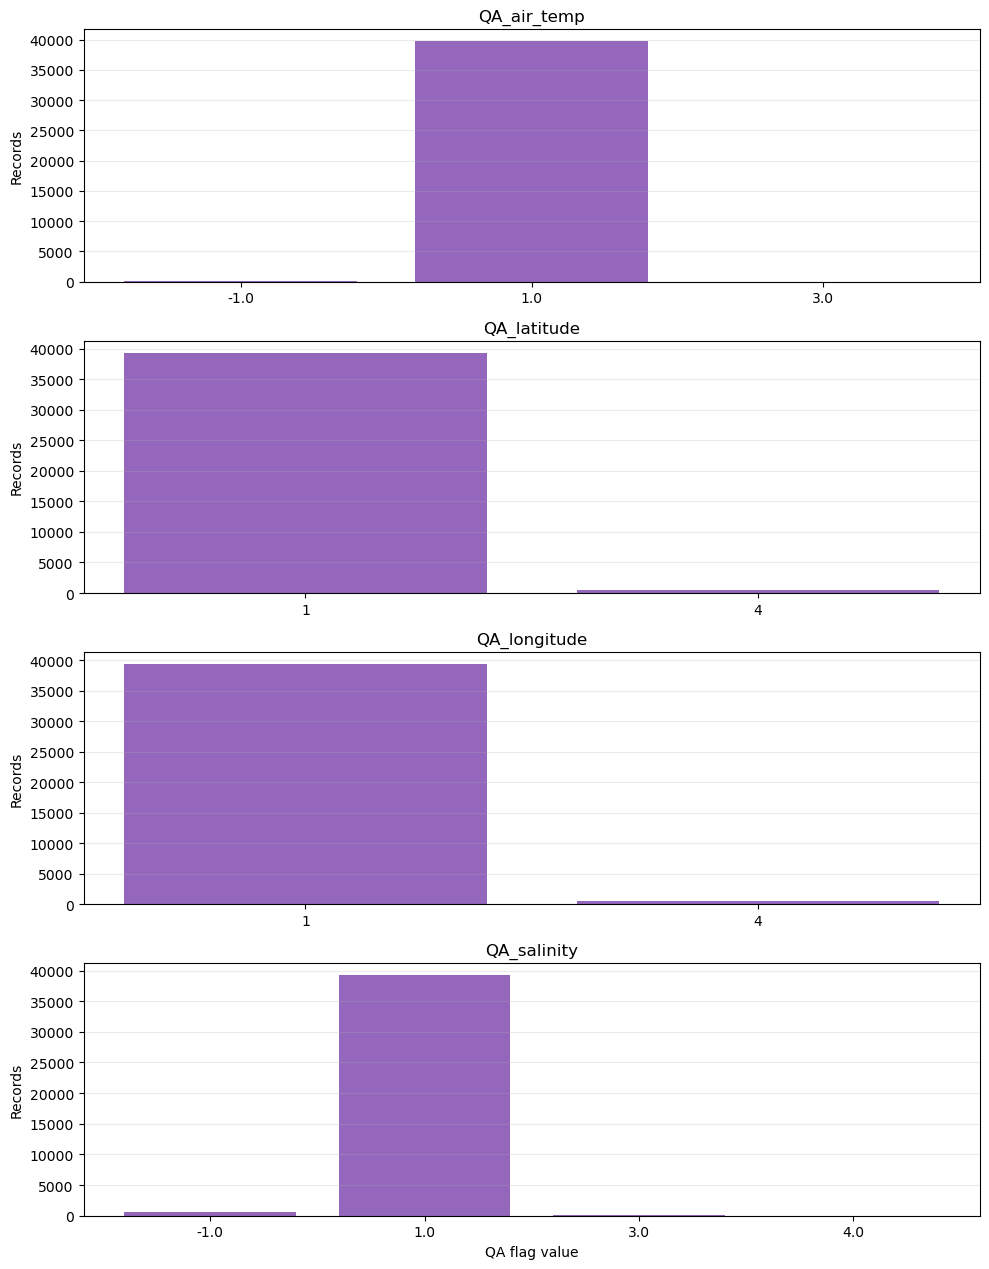

In [12]:
qa_frequency_tables = {}

for col in QA_COLUMNS:
    freq = (
        analysis_df[col]
        .fillna(-1)
        .value_counts(dropna=False)
        .rename_axis("flag")
        .reset_index(name="records")
        .sort_values("flag")
    )
    qa_frequency_tables[col] = freq

plot_qa_columns = [col for col in QA_COLUMNS if not qa_frequency_tables[col].empty][:4]

for col in plot_qa_columns:
    print(f"\n{col}")
    display(qa_frequency_tables[col])

if not plot_qa_columns:
    print("No QA columns are available for plotting.")
else:
    fig, axes = plt.subplots(len(plot_qa_columns), 1, figsize=(10, 3.2 * len(plot_qa_columns)))

    if len(plot_qa_columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_qa_columns):
        freq = qa_frequency_tables[col]
        ax.bar(freq["flag"].astype(str), freq["records"], color="tab:purple")
        ax.set_title(col)
        ax.set_ylabel("Records")
        ax.grid(axis="y", alpha=0.25)

    axes[-1].set_xlabel("QA flag value")
    plt.tight_layout()
    plt.show()


## Summary

### Potential Predictor Variables
| Variable group | Role in HAB pipeline | Use as |
|----------------|----------------------|--------|
| `water_temp`, `air_temp`, `salinity`, `ph`, `dissoxygen`, `secchidisk`, `windspeed` | Local water and atmospheric conditions tied to bloom formation | ML features |
| `spec_name`, `abundance`, `count` | Direct phytoplankton observations and bloom intensity signals | ML features or labels depending on task |
| `sample_site`, `latitude`, `longitude`, `time`, `week_start`, `year`, `month` | Spatial and temporal alignment with other datasets | Join keys / aggregation fields |
| `QA_*` columns | Measurement and site quality flags | Filters / audit fields |

This notebook writes the raw NOAA export to CSV and keeps all cleaning inside `analysis_df`, so the saved export remains a faithful merged pull of the ERDDAP fields selected above.

For the current project scope, PMN is best used as a **supporting California-weekly feature dataset**. It does not provide complete coverage of the full CalHABMAP California pier list, so any merged modeling table should treat PMN as a **partial auxiliary source** rather than a complete pier-matched HAB dataset.

The strongest current overlap with CalHABMAP is:
- `CA - Santa Cruz wharf` -> `SantaCruzWharf_86b0_cc60_0457`
- `CA - Sea Center` -> `StearnsWharf_eff4_30b3_6677`
- `CA - Wharf 2 Monterey CA` -> `MontereyWharf_1e75_40db_c5ad`
